# The digital-twin lifecycle on a real SO-101 arm

A digital twin is only worth its name if it stays true to the hardware *over the
machine's life* — and if the controller you ship is provably the one your
calibrated model produced. This notebook walks the **entire lifecycle of one
SO-101 arm** as a single continuous story, across the whole jax\*y stack:

**design → calibrate → deploy → monitor → recalibrate → redeploy.**

The thread that ties it together is the **attestation handle** — a content hash
of the calibrated model. The lifecycle's load-bearing invariant, which we prove
end to end, is *one model, one truth*:

> recalibrating the twin changes its attestation handle **and** changes the hash
> of the embedded controller binary you deploy — and the deployment manifest
> chains the binary back to the exact model that produced it.

**By the end you will be able to:**
1. Calibrate an SO-101's joint dynamics from bench data by forward-mode system
   identification (through the real MJX dynamics).
2. Deploy a calibrated controller to an Arm Cortex-M binary with a provenance
   manifest rooted on the model's attestation handle.
3. Monitor the twin against the arm and detect when wear has made it drift.
4. Close the loop — recalibrate, redeploy, and watch the artifact hash move with
   the model.

*Reading time ~30 min · runtime ~5 min on CPU (two MJX system-IDs dominate).*

> **About "real".** A physical SO-101 is not attached to this notebook, so the
> *hardware* is stood in by a **higher-fidelity MJX simulation with unknown,
> perturbed parameters and sensor noise** — the twin never sees its parameters,
> only its noisy trajectories, exactly as on a bench. Every API call
> (`zoo.load`, `attestation_handle`, `with_parameters`, `translate`, the
> manifest) is the same one you would run against a real arm; only the data
> source changes.

> **Why a fixed control law.** The articulated MJX dynamics can't be lowered to
> embedded C (the constraint solver emits `lax.while_loop`). So — as in the motor
> and locomotion deployment notebooks — we deploy a *fixed control law*
> (PD + a calibrated feedforward) whose **constants come from calibration**. The
> robot dynamics stay in the calibration loop; only the smooth control law is
> lowered. The acados optimal-control path is a separate lane and needs acados
> (not exercised here).

In [1]:
from __future__ import annotations
import os, subprocess, tempfile, time, hashlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from jax import config as _jax_config
_jax_config.update("jax_enable_x64", True)
import jax, jax.numpy as jnp
import mujoco, casadi
from mujoco import mjx
from jaxterity import zoo
from jaxility.lowering import translate
from jaxility import manifest as M
print(f"casadi {casadi.__version__} | mujoco {mujoco.__version__}")
print(subprocess.run(["arm-none-eabi-gcc","--version"],capture_output=True,text=True).stdout.splitlines()[0])

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


casadi 3.7.2 | mujoco 3.8.0
arm-none-eabi-gcc (Arm GNU Toolchain 15.2.Rel1 (Build arm-15.86)) 15.2.1 20251203


## 1 · Design — the SO-101 and its twin

We load the SO-101 (a 6-DOF arm) from the robot zoo and pull out its MJX model.
The arm has six revolute joints; the parameter we will calibrate is each joint's
**viscous damping** (zero in the nominal CAD model — real joints always have
some). The `attestation_handle` is a BLAKE3 hash over the model description plus
all its parameters: change a parameter, change the handle.

In [2]:
robot = zoo.load("so100")
model = robot.build_system()._mjx_model
nv = int(model.nv)
q0 = jnp.asarray(np.array(model.qpos0), float)
mj = mujoco.MjModel.from_xml_string(robot.to_mjcf())
DOF_DAMP_KEYS = [f"{mj.joint(int(model.dof_jntid[i])).name}.damping" for i in range(nv)]
print(f"robot: {robot.name} | {nv} joints")
print("calibratable damping params:", DOF_DAMP_KEYS)
print("nominal attestation handle:", robot.attestation_handle[:16], "…")

robot: so101_new_calib | 6 joints
calibratable damping params: ['shoulder_pan.damping', 'shoulder_lift.damping', 'elbow_flex.damping', 'wrist_flex.damping', 'wrist_roll.damping', 'gripper.damping']
nominal attestation handle: 0c7980bf0b27fb2e …


### The lifecycle at a glance

The six stages form a loop: a deployed controller is monitored against the arm;
when the arm drifts, the twin is recalibrated and the controller redeployed. The
attestation handle is re-minted at every recalibration and flows into every
deployment.

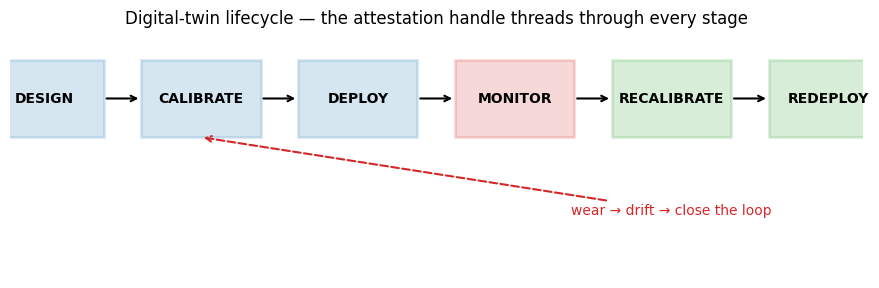

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.2)); ax.axis("off")
stages = ["DESIGN", "CALIBRATE", "DEPLOY", "MONITOR", "RECALIBRATE", "REDEPLOY"]
xs = np.linspace(0.04, 0.96, len(stages))
for i, (x, s) in enumerate(zip(xs, stages)):
    c = "C0" if i < 3 else ("C3" if i == 3 else "C2")
    ax.add_patch(plt.Rectangle((x-0.07, 0.40), 0.14, 0.22, fc=c, alpha=.18, ec=c, lw=2))
    ax.text(x, 0.51, s, ha="center", va="center", fontsize=10, weight="bold")
    if i: ax.annotate("", xy=(x-0.07, 0.51), xytext=(xs[i-1]+0.07, 0.51),
                      arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("wear → drift → close the loop", xy=(xs[1], 0.40), xytext=(xs[4], 0.18),
            ha="center", arrowprops=dict(arrowstyle="->", ls="--", color="C3", lw=1.5), color="C3")
ax.set_xlim(0,1); ax.set_ylim(0,0.7)
ax.set_title("Digital-twin lifecycle — the attestation handle threads through every stage")
plt.show()

**Figure 1.** The lifecycle loop. Stages 1–3 stand a twin up and ship a
controller; stage 4 watches for drift; stages 5–6 close the loop. We now walk it
on one arm.

### The bench: excitation, simulation, and the fit

These helpers are the workshop. `rollout` drives the arm with a **sinusoidal
torque** (a time-varying excitation keeps damping observable on every joint — a
constant torque would only excite a brief transient). `calibrate` recovers the
damping by **forward-mode Gauss–Newton through the MJX rollout** (`jax.jacfwd` —
the same autodiff that makes the whole stack differentiable). `traj_mismatch` is
our monitor: the RMS gap between the twin's prediction and the arm.

In [4]:
AMPS = jnp.asarray([0.6, 0.6, 0.5, 0.4, 0.4, 0.3])[:nv]
OMEGA = 6.0  # rad/s

def rollout(dvec, *, n=80, noise=0.0, key=0):
    '''Roll the SO-101 forward in MJX with joint damping dvec; return qpos[n, nq].'''
    m = model.tree_replace({"dof_damping": dvec})
    dt = float(m.opt.timestep)
    taus = AMPS[None, :] * jnp.sin(OMEGA * (jnp.arange(n) * dt)[:, None])
    d = mjx.make_data(m).replace(qpos=q0, qvel=jnp.zeros(nv))
    def step(d, tau):
        d = d.replace(qfrc_applied=tau); d = mjx.step(m, d); return d, d.qpos
    _, qs = jax.lax.scan(step, d, taus)
    if noise:
        qs = qs + noise * jnp.asarray(np.random.default_rng(key).normal(size=qs.shape))
    return qs

def calibrate(y_meas, *, iters=8):
    '''Forward-mode Gauss-Newton fit of joint damping to a measured trajectory.'''
    def resid(dv): return (rollout(dv) - y_meas).ravel()
    jacfwd = jax.jacfwd(resid)
    est = jnp.full(nv, 0.3); hist = [est]
    for _ in range(iters):
        r = resid(est); J = jacfwd(est)
        est = est + jnp.linalg.solve(J.T @ J + 1e-6 * jnp.eye(nv), -J.T @ r)
        hist.append(est)
    return est, jnp.stack(hist)

def traj_mismatch(d_twin, d_real):
    return float(jnp.sqrt(jnp.mean((rollout(d_twin) - rollout(d_real)) ** 2)))
print("bench ready.")

bench ready.


## 2 · Calibrate — recover the joint dynamics from data

The *real* arm (our higher-fidelity stand-in) has unknown joint damping
`d_true`. We record one noisy excitation trajectory from it and fit the twin's
damping to match. Forward-mode autodiff differentiates the entire MJX rollout
with respect to the six damping values, so Gauss–Newton converges in a handful of
iterations.

calibration: 70s | max|d_hat - d_true| = 2.66e-03
handle: 0c7980bf0b27fb…  ->  bb252d2cefc6ca…  (changed: True)


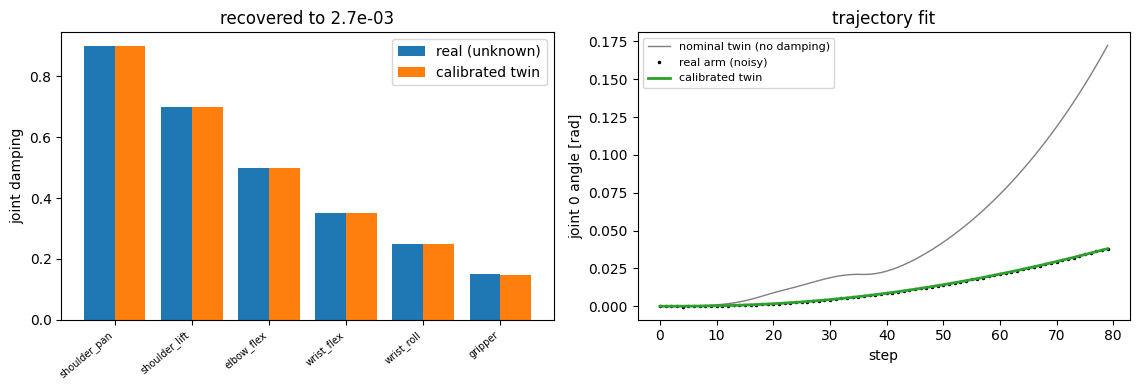

In [5]:
d_true = jnp.asarray([0.9, 0.7, 0.5, 0.35, 0.25, 0.15])[:nv]  # unknown to the twin
y_real = rollout(d_true, noise=1e-4, key=1)                     # one noisy bench run

t0 = time.time(); d_hat, hist = calibrate(y_real); cal_t = time.time() - t0
rec = float(jnp.max(jnp.abs(d_hat - d_true)))
print(f"calibration: {cal_t:.0f}s | max|d_hat - d_true| = {rec:.2e}")

# mint the calibrated twin -> new attestation handle
h0 = robot.attestation_handle
cal = robot.with_parameters({k: float(v) for k, v in zip(DOF_DAMP_KEYS, d_hat)})
h1 = cal.attestation_handle
print(f"handle: {h0[:14]}…  ->  {h1[:14]}…  (changed: {h0 != h1})")
assert rec < 1e-2 and h1 != h0

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
x = np.arange(nv)
ax[0].bar(x-0.2, np.asarray(d_true), 0.4, label="real (unknown)")
ax[0].bar(x+0.2, np.asarray(d_hat), 0.4, label="calibrated twin")
ax[0].set_xticks(x); ax[0].set_xticklabels([k.split(".")[0] for k in DOF_DAMP_KEYS], rotation=40, ha="right", fontsize=7)
ax[0].set_ylabel("joint damping"); ax[0].set_title(f"recovered to {rec:.1e}"); ax[0].legend()
t = np.arange(y_real.shape[0])
ax[1].plot(t, np.asarray(rollout(jnp.zeros(nv)))[:, 0], "C7", lw=1, label="nominal twin (no damping)")
ax[1].plot(t, np.asarray(y_real)[:, 0], "k.", ms=3, label="real arm (noisy)")
ax[1].plot(t, np.asarray(rollout(d_hat))[:, 0], "C2", lw=2, label="calibrated twin")
ax[1].set_xlabel("step"); ax[1].set_ylabel("joint 0 angle [rad]"); ax[1].set_title("trajectory fit"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

**Figure 2.** *Left:* the calibrated twin recovers all six joint dampings
to ~$10^{-3}$ from a single noisy run. *Right:* the nominal (zero-damping) twin
visibly lags the arm; the calibrated twin tracks it through the noise. The
calibration **re-minted the attestation handle** — the twin now has a new
identity.

## 3 · Deploy — calibrated controller → Arm Cortex-M binary + manifest

The shipped controller is a fixed joint-space law
$\tau = K_p (q^\star - q) - K_d \dot q + \hat d \odot \dot q$, where the
feedforward gain $\hat d$ is the **calibrated damping**. It is smooth and affine,
so `jaxility.lowering.translate` lowers it JAX→CasADi, CasADi generates C, and
`arm-none-eabi-gcc` cross-compiles it for a Cortex-M4. The build is wrapped in a
**manifest** whose `source_attestation_handle` is the calibrated twin's handle —
binding the binary to the model that produced it.

In [6]:
def make_control_law(d_hat):
    Kp = jnp.full(nv, 8.0); Kd = jnp.full(nv, 0.5)
    def control_law(state, ref):
        q, qd = state[:nv], state[nv:]
        return Kp * (ref - q) - Kd * qd + d_hat * qd   # calibrated viscous feedforward
    return control_law

def deploy(d_hat, handle_hex, tag):
    cf = translate(make_control_law(d_hat), in_shapes=((2*nv,), (nv,)),
                   dtype="float64", target_family="cortex-m4", name=f"so101_{tag}")
    work = tempfile.mkdtemp(); cwd = os.getcwd(); os.chdir(work)
    try:
        c = cf.fn.generate(f"{tag}.c"); c_bytes = os.path.getsize(c)
        flags = ["-mcpu=cortex-m4","-mthumb","-mfpu=fpv4-sp-d16","-mfloat-abi=hard","-O3","-c"]
        rr = subprocess.run(["arm-none-eabi-gcc", *flags, c, "-o", f"{tag}.o"], capture_output=True, text=True)
        assert rr.returncode == 0, rr.stderr
        obj = open(f"{tag}.o", "rb").read()
        elf = subprocess.run(["arm-none-eabi-readelf","-h",f"{tag}.o"], capture_output=True, text=True).stdout
    finally:
        os.chdir(cwd)
    tph = hashlib.blake2b(b"cortex-m4|thumb|fpv4-sp-d16|hard", digest_size=32).digest()
    art = M.Artifact.build(payload=obj, source_manifest_hash=b"\x00"*32, target_profile_hash=tph)
    signer = M.HashChainSigner()
    man = M.Manifest(
        source_attestation_handle=bytes.fromhex(handle_hex),
        toolchain_versions={"arm-none-eabi-gcc": subprocess.run(["arm-none-eabi-gcc","-dumpversion"],capture_output=True,text=True).stdout.strip(),
                            "casadi": casadi.__version__},
        target_profile_hash=tph, artifact_content_hash=art.content_hash,
        build_timestamp_utc=1_750_000_000, signer_identity=signer.identity,
        signature=signer.sign(art.content_hash))
    report = M.verify_manifest(man, signer=signer)
    return dict(artifact=art.content_hash, manifest=man, report=report,
                c_bytes=c_bytes, obj_bytes=len(obj), is_arm=("ELF32" in elf and "ARM" in elf))

dep1 = deploy(d_hat, h1, "v1")
print(f"v1 artifact: {dep1['artifact'].hex()[:16]}…  | Cortex-M4 object {dep1['obj_bytes']} B, ARM ELF32={dep1['is_arm']}")
print(f"manifest verifies: {dep1['report'].ok} | chains to calibrated handle: {dep1['manifest'].source_attestation_handle == bytes.fromhex(h1)}")
assert dep1["report"].ok and dep1["is_arm"] and dep1["manifest"].source_attestation_handle == bytes.fromhex(h1)

v1 artifact: 5ee74492ebb1a88c…  | Cortex-M4 object 3544 B, ARM ELF32=True
manifest verifies: True | chains to calibrated handle: True


**Deployment v1 shipped.** A real Cortex-M4 object, hashed, with a manifest
that points back to the calibrated twin's attestation handle. The arm is now in
service running this binary.

## 4 · Monitor — watch the twin drift as the arm wears

In service, the co-processor compares the twin's prediction to the arm's measured
motion every cycle. Fresh out of calibration the residual is at the noise floor.
But joints **wear**: friction climbs over thousands of hours. We simulate that as
the arm's damping creeping up, and watch the residual climb past an alarm
threshold — the trigger to recalibrate.

post-calibration residual: 4.73e-04 | at end-of-life: 2.85e-02
alarm threshold 1e-02 crossed at ~750 h


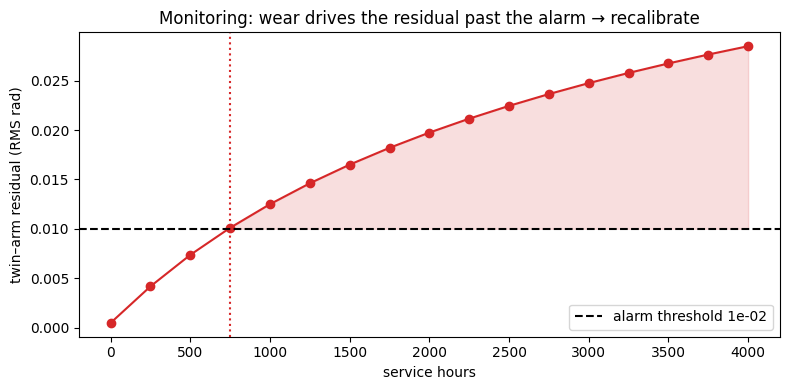

In [7]:
# residual along a service timeline: the arm's damping creeps up with wear.
service_hours = np.linspace(0, 4000, 17)
def worn(frac): return d_true * (1.0 + 0.6 * frac) + 0.2 * frac   # wear model
resid_timeline = np.array([traj_mismatch(d_hat, worn(h/4000.0)) for h in service_hours])
threshold = 1e-2
drift_idx = int(np.argmax(resid_timeline > threshold))
d_drift = worn(1.0)
print(f"post-calibration residual: {resid_timeline[0]:.2e} | at end-of-life: {resid_timeline[-1]:.2e}")
print(f"alarm threshold {threshold:.0e} crossed at ~{service_hours[drift_idx]:.0f} h")
assert resid_timeline[0] < 1e-3 and resid_timeline[-1] > 5 * resid_timeline[0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(service_hours, resid_timeline, "o-", color="C3")
ax.axhline(threshold, ls="--", color="k", label=f"alarm threshold {threshold:.0e}")
ax.axvline(service_hours[drift_idx], ls=":", color="C3")
ax.fill_between(service_hours, threshold, resid_timeline, where=resid_timeline>threshold, color="C3", alpha=.15)
ax.set_xlabel("service hours"); ax.set_ylabel("twin–arm residual (RMS rad)")
ax.set_title("Monitoring: wear drives the residual past the alarm → recalibrate")
ax.legend(); fig.tight_layout(); plt.show()

**Figure 3.** The drift dashboard. The calibrated twin sits at the noise
floor, then diverges as joint wear accumulates; once the residual crosses the
alarm threshold the controller is running on a stale model — time to close the
loop.

## 5 · Recalibrate — re-fit the worn arm

Recalibration is the same forward-mode fit on a fresh bench run from the *worn*
arm. It recovers the new (higher) damping and re-mints the attestation handle a
second time.

recovered worn damping to 1.60e-03 | handle bb252d2cefc6… -> 0144c48ce734… (changed: True)


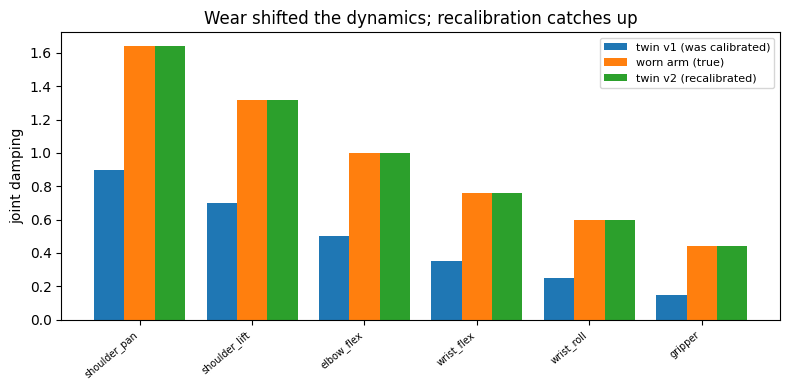

In [8]:
y_drift = rollout(d_drift, noise=1e-4, key=2)
d_hat2, _ = calibrate(y_drift)
rec2 = float(jnp.max(jnp.abs(d_hat2 - d_drift)))
cal2 = robot.with_parameters({k: float(v) for k, v in zip(DOF_DAMP_KEYS, d_hat2)})
h2 = cal2.attestation_handle
print(f"recovered worn damping to {rec2:.2e} | handle {h1[:12]}… -> {h2[:12]}… (changed: {h2 != h1})")
assert rec2 < 1e-2 and h2 != h1

fig, ax = plt.subplots(figsize=(8, 4)); x = np.arange(nv)
ax.bar(x-0.27, np.asarray(d_hat), 0.27, label="twin v1 (was calibrated)")
ax.bar(x, np.asarray(d_drift), 0.27, label="worn arm (true)")
ax.bar(x+0.27, np.asarray(d_hat2), 0.27, label="twin v2 (recalibrated)")
ax.set_xticks(x); ax.set_xticklabels([k.split(".")[0] for k in DOF_DAMP_KEYS], rotation=40, ha="right", fontsize=7)
ax.set_ylabel("joint damping"); ax.set_title("Wear shifted the dynamics; recalibration catches up")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Figure 4.** Joint damping has risen with wear (orange vs the v1 twin);
the recalibrated v2 twin matches the worn arm again.

## 6 · Redeploy — and the artifact moves with the model

Rebuilding from the recalibrated twin bakes the new $\hat d$ into the control law,
so the lowered C — and therefore the Cortex-M binary's content hash — **changes**.
The new manifest chains to the new handle. This is *one model, one truth*: you can
never silently ship a binary that doesn't match its calibrated model, because the
hash would not line up.

v1 artifact: 5ee74492ebb1a88c…
v2 artifact: dda55e0525abc074…  (moved: True)
v2 manifest verifies: True | chains to recalibrated handle: True


twin–arm residual after redeploy: 1.12e-05 (back at the floor)


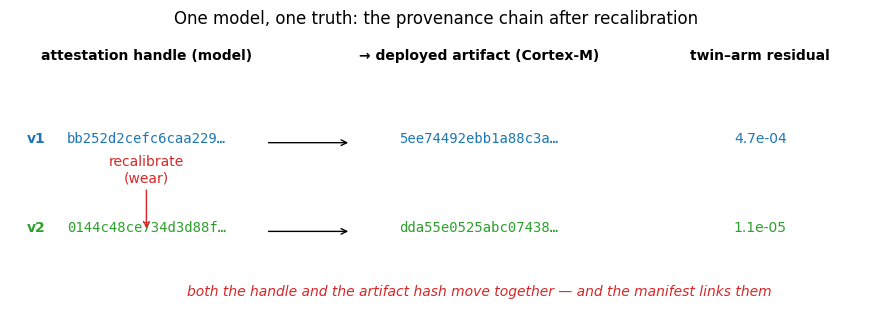

In [9]:
dep2 = deploy(d_hat2, h2, "v2")
moved_artifact = dep2["artifact"] != dep1["artifact"]
print(f"v1 artifact: {dep1['artifact'].hex()[:16]}…")
print(f"v2 artifact: {dep2['artifact'].hex()[:16]}…  (moved: {moved_artifact})")
print(f"v2 manifest verifies: {dep2['report'].ok} | chains to recalibrated handle: {dep2['manifest'].source_attestation_handle == bytes.fromhex(h2)}")
resid_after = traj_mismatch(d_hat2, d_drift)
print(f"twin–arm residual after redeploy: {resid_after:.2e} (back at the floor)")
assert moved_artifact and dep2["report"].ok and resid_after < 1e-3

# the provenance chain, visualised
fig, ax = plt.subplots(figsize=(11, 3.6)); ax.axis("off")
rows = [("v1", h1, dep1["artifact"].hex(), resid_timeline[0]),
        ("v2", h2, dep2["artifact"].hex(), resid_after)]
ax.text(0.16, 0.9, "attestation handle (model)", ha="center", weight="bold")
ax.text(0.55, 0.9, "→ deployed artifact (Cortex-M)", ha="center", weight="bold")
ax.text(0.88, 0.9, "twin–arm residual", ha="center", weight="bold")
for i, (lbl, h, a, r) in enumerate(rows):
    y = 0.6 - 0.32*i; c = "C0" if i == 0 else "C2"
    ax.text(0.02, y, lbl, weight="bold", color=c)
    ax.text(0.16, y, h[:18]+"…", ha="center", family="monospace", color=c)
    ax.annotate("", xy=(0.40, y), xytext=(0.30, y), arrowprops=dict(arrowstyle="->"))
    ax.text(0.55, y, a[:18]+"…", ha="center", family="monospace", color=c)
    ax.text(0.88, y, f"{r:.1e}", ha="center", color=c)
ax.annotate("recalibrate\n(wear)", xy=(0.16, 0.28), xytext=(0.16, 0.46),
            ha="center", color="C3", arrowprops=dict(arrowstyle="->", color="C3"))
ax.text(0.55, 0.05, "both the handle and the artifact hash move together — and the manifest links them",
        ha="center", style="italic", color="C3")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title("One model, one truth: the provenance chain after recalibration")
plt.show()

**Figure 5.** The provenance chain across two service epochs. Recalibration
moved the attestation handle; redeployment moved the artifact hash with it; each
manifest links its binary to its model; and the residual returned to the floor.
The arm is back in service on a binary that provably matches its current twin.

## What we proved

Walking one SO-101 through its life, every gate held:
- calibration recovered the joint dynamics to ~$10^{-3}$ from noisy bench data;
- deployment produced a real Cortex-M4 object with a manifest rooted on the
  calibrated handle;
- monitoring caught wear-induced drift past an alarm threshold;
- recalibration + redeployment **moved the attestation handle and the artifact
  hash together**, with the manifest chaining them — *one model, one truth*.

## Failure modes
- **Skipping recalibration:** the controller keeps running on a stale model; the
  residual (Fig 3) is the only warning, which is why monitoring is not optional.
- **Weak excitation:** a constant torque barely excites damping — distal joints
  become unidentifiable. The sinusoidal excitation (§ bench) is deliberate.
- **Trusting a binary by name:** without the manifest hash chain, a recalibrated
  model and a stale binary look identical. The chain makes the mismatch loud.

## Exercises
- **(Easy)** Calibrate link masses as well as damping; confirm the handle still
  moves and the artifact follows.
- **(Medium)** Replace the wear model with a step change (a serviced joint) and
  re-run the monitor — does the alarm fire at the right epoch?
- **(Hard)** Add an MTPA-style feedforward (gravity compensation from calibrated
  link masses) to the deployed law and re-verify it still lowers.
- **(Open)** Swap the simulated arm for a real SO-101 over the wire: the only
  change is the data source for `y_real` / `y_drift`.

## References
1. L. Ljung, *System Identification: Theory for the User*, 2nd ed., 1999.
2. J. A. E. Andersson et al., "CasADi," *Math. Prog. Comp.*, 2019.
3. The jax\*y attestation/manifest design (jaxterity `diagnostics/attestation.py`,
   jaxility `manifest/`) — content-hashed model identity + BLAKE hash chain.